> Note: have a look at *ML_HOBE* notebook for a more detailed analysis of the data and the baseline model

> Make sure to install **presto_eokit** library: https://github.com/DHI/presto-eokit

In [1]:
import os

import numpy as np
import torch 
import pandas as pd
import seaborn as sns
from joblib import dump, load
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import presto_eokit
from presto_eokit import Presto
from presto_eokit.utils import set_seed, seed_worker
from sklearn.ensemble import HistGradientBoostingRegressor

from dhi_mleo.plot import (
    corr_matrix, corr_target, corr_bar,
    plot_predictions_by_station
)
from dhi_mleo.stats import regression_metrics,  loso_cv_ml

from utils import preprocess_sensor_data

import warnings
warnings.filterwarnings('ignore')

In [3]:
# set seed to ensure reproducibility if needed
set_seed(42) 

Seed set to 42


Random seed set as 42


# Prepare the Data

In [ ]:
# CONFIG
DATA_PATH_A = "../data/HOBE/hub/insitu/sm_features_sensor_typeA.csv"
DATA_PATH_B = "../data/HOBE/hub/insitu/sm_features_sensor_typeB.csv"
TARGET_COLUMN = "INSITU_SM"
SENSOR_OPTION = "AVG"   # "A" = only Sensor A, "B" = only Sensor B, "AVG" = average when both exist we take the avergae

In [8]:
df_A = pd.read_csv(DATA_PATH_A)
df_B = pd.read_csv(DATA_PATH_B)

data = preprocess_sensor_data(df_A=df_A, df_B=df_B, sensor_option=SENSOR_OPTION, target_column=TARGET_COLUMN)
#data.drop(columns=['Unnamed: 0'], inplace=True)

In [9]:
data["Date"] = pd.to_datetime(data["Date"]) 
data['Month'] = data['Date'].dt.month
SM_S2_BANDS = {
    'REFL_band1': "B2",
    'REFL_band2': "B3",
    'REFL_band3': "B4",
    'REFL_band4': "B5",
    'REFL_band5': "B6",
    'REFL_band6': "B7",
    'REFL_band7': "B8A",
    'REFL_band8': "B11",
    'REFL_band9': "B12"
}
data = data.rename(columns=SM_S2_BANDS)

### Add Spectral indices related to SM and our Modelled SM

In [10]:
data['INSITU_SM'] = data['INSITU_SM'] * 100
data['weighted_sm'] = (data['20_RZSM_band1'] + data['20_RZSM_band2']) / 2

data['NDVI'] = (data["B8A"] - data["B4"]) / (data["B8A"] + data["B4"])
data['MNDWI'] = (data["B3"] - data["B11"]) / (data["B3"] + data["B11"])
data['NMDI'] =  (data["B8A"] - (data["B11"] - data["B12"])) / (data["B8A"] + (data["B11"] - data["B12"]))
data["PSRI"] = (data["B4"] - data["B2"]) / (data["B8A"])
data["VARI_red_edge"] = (data["B5"] - (1.7 * data["B4"]) + (0.7 * data["B2"])) / (data["B5"] + (2.3 * data["B4"]) - (1.3 * data["B2"]))
data["BSI"] = ((data["B11"] + data["B4"]) - (data["B8A"] + data["B2"])) / ((data["B11"] + data["B4"]) + (data["B8A"] + data["B2"]))

In [11]:
data[["INSITU_SM", "weighted_sm"]].describe()

,INSITU_SM,weighted_sm
count,6546.000000,8760.000000
mean,19.337296,27.501011
std,10.454520,9.427447
min,0.100000,7.700000
25%,11.723958,23.635492
50%,18.250000,26.673350
75%,24.474479,30.538210
max,82.387500,57.815874


- Lets keep only the data where the INSITU SM is available
- We will also ignore the data where the type of the Land is "Forest" because we would like to use the data for moddeling SM over agriculture areas (Health land will also be considered)

In [12]:
LANDCOVER_EXCLUDE = ["Forest"] 

df_non_missing_target = data[data['INSITU_SM'].notna()]
excluded_stations = df_non_missing_target[df_non_missing_target["Land"].isin(LANDCOVER_EXCLUDE)]["Station"].unique()
df_filtered = df_non_missing_target[~df_non_missing_target["Station"].isin(excluded_stations)]
print("Final dataset shape:", df_filtered.shape)

Final dataset shape: (5329, 87)


- The data will also be split into training and test sets based on time intervals to prevent [data leakage](https://en.wikipedia.org/wiki/Leakage_(machine_learning)).

In [13]:
df_filtered = df_filtered.reset_index(drop=True)
df_valid_train = df_filtered[df_filtered.Date < "2018-07-01"]
df_valid_test =  df_filtered[(df_filtered['Date'] >= "2018-07-01") & (df_filtered['Date'] <= "2019-01-01")]

In [14]:
df_valid_train[["INSITU_SM", "weighted_sm"]].describe()

,INSITU_SM,weighted_sm
count,3012.000000,3012.000000
mean,22.475347,28.715368
std,12.698681,8.309360
min,2.275000,8.113762
25%,13.163542,24.477100
50%,20.488542,27.003379
75%,28.090104,31.275685
max,82.387500,57.815874


# Embeddings Extraction

## Prepare Data for Presto

- These is simply the data converted from dataframe to torch format and as expeted by Presto

In [16]:
selected_feat = ["Latitude", "Longitude", "Station", "Month", 'INSITU_SM'] + [*SM_S2_BANDS.values()]

df_valid_train_clean = df_valid_train[selected_feat].copy()
df_valid_train_clean = df_valid_train_clean.rename(columns=SM_S2_BANDS)

df_valid_test_clean = df_valid_test[selected_feat].copy()
df_valid_test_clean = df_valid_test_clean.rename(columns=SM_S2_BANDS)
df_valid_test_clean

,Latitude,Longitude,Station,Month,INSITU_SM,B2,B3,B4,B5,B6,B7,B8A,B11,B12
3012,56.0193,9.1809,1.01,7,4.795833,380.000000,547.333313,601.000000,1111.000000,1947.666626,2241.666748,2538.000000,2561.333252,1454.333374
3013,56.0283,9.1654,1.03,7,7.183333,294.333344,454.666656,511.000000,996.000000,1815.666626,2085.666748,2505.666748,2228.333252,1181.333374
3014,56.0513,9.1610,1.06,7,7.439583,398.333344,666.333313,507.333344,1179.333374,3579.333252,4379.333496,4627.666504,2602.666748,1527.000000
3015,56.0426,9.1413,1.07,7,5.938462,470.399994,746.000000,851.000000,1385.400024,2153.199951,2571.199951,2970.399902,2851.600098,1798.599976
3016,56.0466,9.1239,1.08,7,9.897917,260.600006,554.400024,270.000000,897.400024,4669.399902,6001.600098,6226.600098,1957.599976,815.400024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5324,55.9354,8.9221,3.02,12,20.464583,588.869568,423.130432,244.739136,413.260864,624.478271,687.782593,708.739136,492.739136,277.260864
5325,55.9121,8.9462,3.03,12,18.681250,987.266663,905.799988,945.799988,1281.333374,1593.133301,1684.533325,1838.533325,1533.000000,1434.000000
5326,55.9025,8.9175,3.05,12,20.018750,536.114258,463.542847,422.942871,678.514282,1130.485718,1253.942871,1328.942871,954.114258,729.314270
5327,55.8776,9.2683,3.08,12,25.777083,318.000000,268.714294,215.000000,598.714294,1382.714233,1648.000000,1774.142822,836.857117,455.000000


In [17]:
# define band config: you can add more bands if available
band_config = {
    "s2": [*SM_S2_BANDS.values()], 
    # "s1": ["VV", "VH"],
    # "era5": ["temperature_2m", "total_precipitation"],
    # "srtm": ["elevation", "slope"],
}

# extractor fn
extractor_fn = presto_eokit.create_extractor(
    band_configs=band_config,
    locations=("Latitude", "Longitude"),
    target_column="INSITU_SM",
    month_column="Month",  # or: date_column="Date"
    timestep_dim=1
)
# extract data as expected from Presto
train_dataset = presto_eokit.data_extractor(df_valid_train_clean, extractor_fn)
test_dataset = presto_eokit.data_extractor(df_valid_test_clean, extractor_fn)

100%|██████████| 2317/2317 [00:00<00:00, 3227.58it/s]


In [18]:
# Make sure to set the generator for deterministic behavior if needed
# This is important for reproducibility, especially when using multiple workers
g = torch.Generator()
g.manual_seed(42)  # use the same seed as in set_seed()

batch_size = 64

train_dl = DataLoader(
    TensorDataset(
        train_dataset[0].float(),      # x
        train_dataset[1].bool(),       # mask
        train_dataset[2].long(),       # dynamic world
        train_dataset[3].float(),      # latlons
        train_dataset[4].float(),      # target
        (train_dataset[5] - 1).long()  # Month corrected to zero-indexed
    ),
    batch_size=batch_size,
    shuffle=False,  
    worker_init_fn=seed_worker,        # This ensures each worker uses a different seed
    generator=g 
)

val_dl = DataLoader(
    TensorDataset(
        test_dataset[0].float(), 
        test_dataset[1].bool(), 
        test_dataset[2].long(), 
        test_dataset[3].float(),  
        test_dataset[4].float(), 
        (test_dataset[5] - 1).long()
    ),
    batch_size=batch_size,
    shuffle=False, 
    worker_init_fn=seed_worker, 
    generator=g 
)

## Extract features using Presto

In [19]:
device = "cpu" #"cuda" if torch.cuda.is_available() else "cpu"

model = Presto.load_pretrained(device)
model.to(device)
model.eval() 

Presto(
  (encoder): Encoder(
    (eo_patch_embed): ModuleDict(
      (S1): Linear(in_features=2, out_features=128, bias=True)
      (S2_RGB): Linear(in_features=3, out_features=128, bias=True)
      (S2_Red_Edge): Linear(in_features=3, out_features=128, bias=True)
      (S2_NIR_10m): Linear(in_features=1, out_features=128, bias=True)
      (S2_NIR_20m): Linear(in_features=1, out_features=128, bias=True)
      (S2_SWIR): Linear(in_features=2, out_features=128, bias=True)
      (ERA5): Linear(in_features=2, out_features=128, bias=True)
      (SRTM): Linear(in_features=2, out_features=128, bias=True)
      (NDVI): Linear(in_features=1, out_features=128, bias=True)
    )
    (dw_embed): Embedding(10, 128)
    (latlon_embed): Linear(in_features=3, out_features=128, bias=True)
    (blocks): ModuleList(
      (0-1): 2 x Block(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)

In [20]:
X_train_np = presto_eokit.features_extractor(model, train_dl, device=device, verbose=True)
X_val_np = presto_eokit.features_extractor(model, val_dl, device=device, verbose=True)

100%|██████████| 37/37 [00:00<00:00, 95.18it/s] 


In [21]:
X_train_np.shape, X_val_np.shape

((3012, 128), (2317, 128))

# Feature Exploration

- In our experimentation we found that adding some of the original features to the Presto features can improve performance.
- We also found that using only 4 embeddings [16, 52, 108, 120] (since numpy index starts from 0, this corresponds to embeddings [17, 53, 109, 121] if we start counting the embeddings from 1) from Presto yield the best results as comnpared to using all the 128 embeddings.

In [22]:
extra_fatures = [
    'ELEV', 
    "ETref", 
    "weighted_sm",
    "20_RZSM_band1", 
    "20_RZSM_band2",
    "Month", 
    "DOY_UTC"
]
# we stack the selected embeddings from the pretrained model with the additional features we have in our dataset
X_train = np.hstack([X_train_np[:, [16, 52, 108, 120]], df_valid_train[extra_fatures].values])
X_test = np.hstack([X_val_np[:, [16, 52, 108, 120]], df_valid_test[extra_fatures].values])

In [23]:
y_train = train_dataset[4].numpy()
y_test = test_dataset[4].numpy()

In [24]:
df_x_train = pd.DataFrame(X_train).reset_index(drop=True)
# Rename the first 5 embedding columns
selected_embeddings = [str(16), str(52), str(108), str(120)]
old_cols = df_x_train.columns[0:5]
df_x_train.rename(columns=dict(zip(old_cols, selected_embeddings)), inplace=True)
# Rename the next extra feature columns 
old_cols = df_x_train.columns[4:11]
df_x_train.rename(columns=dict(zip(old_cols, extra_fatures)), inplace=True)
# Add target variable
df_x_train["INSITU_SM"] = df_valid_train_clean["INSITU_SM"]

In [25]:
df_x_test = pd.DataFrame(X_test)
selected_embeddings = [str(16), str(52), str(108), str(120)]
old_cols = df_x_test.columns[0:5]
df_x_test.rename(columns=dict(zip(old_cols, selected_embeddings)), inplace=True)
old_cols = df_x_test.columns[4:11]
df_x_test.rename(columns=dict(zip(old_cols, extra_fatures)), inplace=True)
df_x_test["INSITU_SM"] = df_valid_test_clean.reset_index(drop=True)["INSITU_SM"]
df_x_test

,16,52,108,120,ELEV,ETref,weighted_sm,20_RZSM_band1,20_RZSM_band2,Month,DOY_UTC,INSITU_SM
0,-2.244879,-0.058782,0.454763,0.622981,59.0,5.016491,16.331830,12.839264,19.824396,7.0,182.0,4.795833
1,-2.108673,-0.087786,0.459079,0.670829,68.0,5.012024,19.176680,18.120087,20.233273,7.0,182.0,7.183333
2,-2.678788,-0.103787,0.328445,0.095247,60.0,5.023180,23.064681,21.246590,24.882772,7.0,182.0,7.439583
3,-2.302787,-0.086757,0.329771,0.507469,60.0,5.029646,10.675080,8.169897,13.180264,7.0,182.0,5.938462
4,-2.537564,-0.185016,0.407310,0.157832,55.0,5.047212,8.500815,5.001630,12.000000,7.0,182.0,9.897917
...,...,...,...,...,...,...,...,...,...,...,...,...
2312,0.766492,1.114549,0.253489,0.569130,28.0,0.274096,24.645606,24.620472,24.670740,12.0,365.0,20.464583
2313,1.277384,0.970094,0.066537,-0.032167,33.0,0.266972,27.581972,27.908970,27.254974,12.0,365.0,18.681250
2314,1.023628,1.024438,0.166419,0.492969,38.0,0.259734,27.506709,27.715672,27.297747,12.0,365.0,20.018750
2315,0.924452,0.884330,0.234990,0.647043,89.0,0.194838,29.590869,29.415861,29.765877,12.0,365.0,25.777083


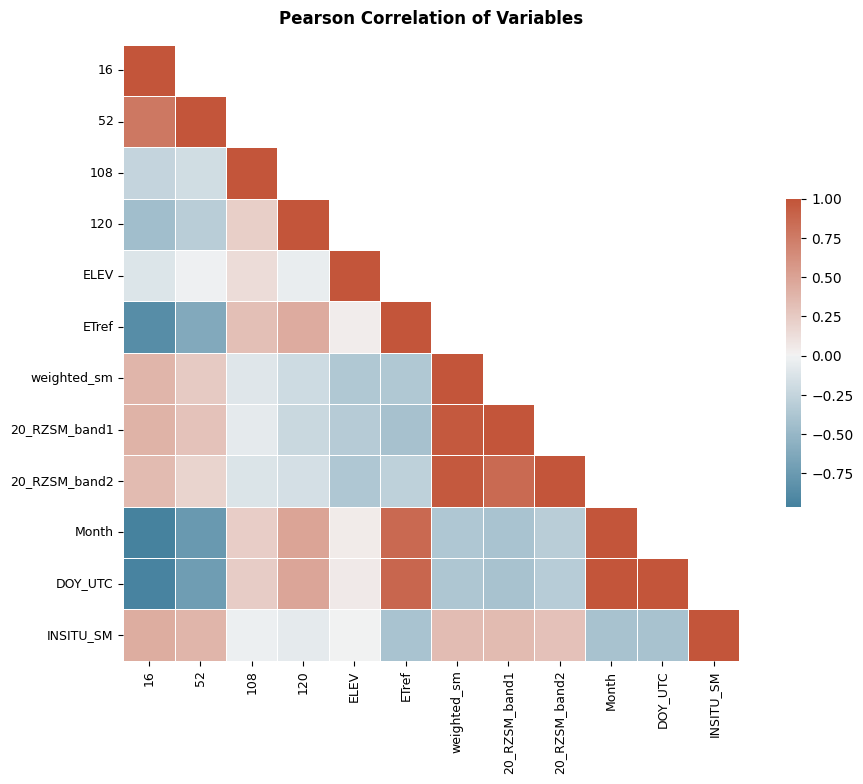

In [26]:
# Correlation matrix
corr_matrix(df_x_train, title="Pearson Correlation of Variables")
plt.show()

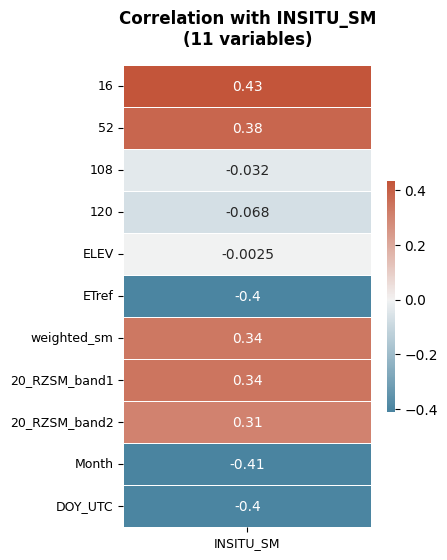

In [27]:
# correlation with SM
corr_target(df_x_train, target="INSITU_SM", figsize=(4,6))
plt.show()

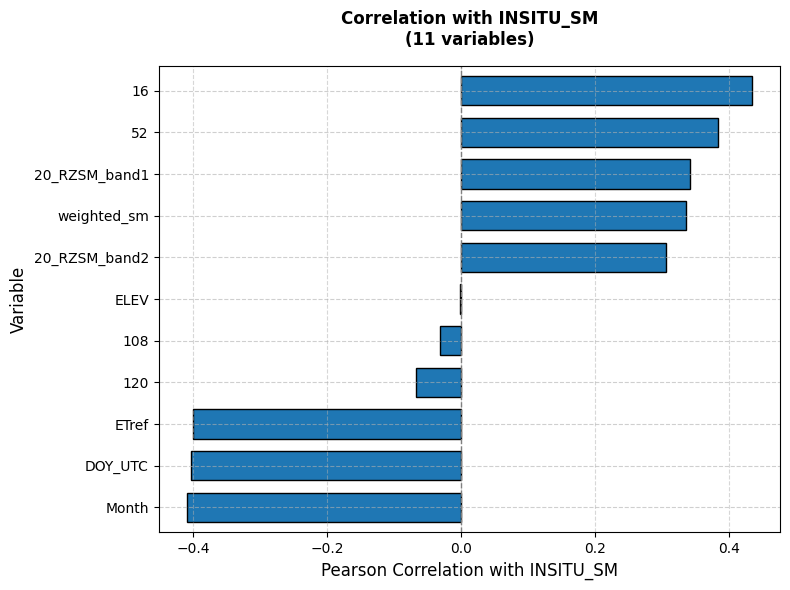

In [28]:
# we could also use a bar plot of correlations
corr_bar(df_x_train, target="INSITU_SM", figsize=(8,6))
plt.show()

# Modelling

## ML Model for Soil Moisture (SM)

In [29]:
hgb = HistGradientBoostingRegressor(random_state=42, max_iter=300)
hgb.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",300
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide ` and:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_categorical.py`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 

In [ ]:
os.makedirs("../data/HOBE/models", exist_ok=True)
dump(hgb, "../data/HOBE/models/presto_histgb_model.joblib")

In [31]:
y_train_pred = hgb.predict(X_train)

In [32]:
train_stats = regression_metrics(y_train, y_train_pred, label="Train", return_results=True)
train_stats

Train Pearson r: 0.9976
Train R²: 0.9952
Train RMSE: 0.8824
Train MAE: 0.6102



{'Pearson_r': np.float64(0.9976136176044433),
 'R2': 0.9951694488268135,
 'RMSE': np.float64(0.8824393158441226),
 'MAE': 0.6101612222904537}

In [33]:
y_pred_test = hgb.predict(X_test)

In [34]:
test_stats = regression_metrics(y_test, y_pred_test, label="Test", return_results=True)
test_stats

Test Pearson r: 0.7958
Test R²: 0.5455
Test RMSE: 4.8531
Test MAE: 3.8764



{'Pearson_r': np.float64(0.7958405105775566),
 'R2': 0.5454593285825793,
 'RMSE': np.float64(4.853111423429693),
 'MAE': 3.876373877152524}

In [25]:
test_stats = regression_metrics(y_test, y_pred_test, label="Test", return_results=True)
test_stats

Test Pearson r: 0.7870
Test R²: 0.5539
Test RMSE: 4.8078
Test MAE: 3.8625



{'Pearson_r': np.float64(0.7870133390232861),
 'R2': 0.5539114002919008,
 'RMSE': np.float64(4.8077784907336385),
 'MAE': 3.8624505578003547}

In [35]:
r, r2, rmse, mae = test_stats.get('Pearson_r'), test_stats.get('R2'), test_stats.get('RMSE'), test_stats.get('MAE')

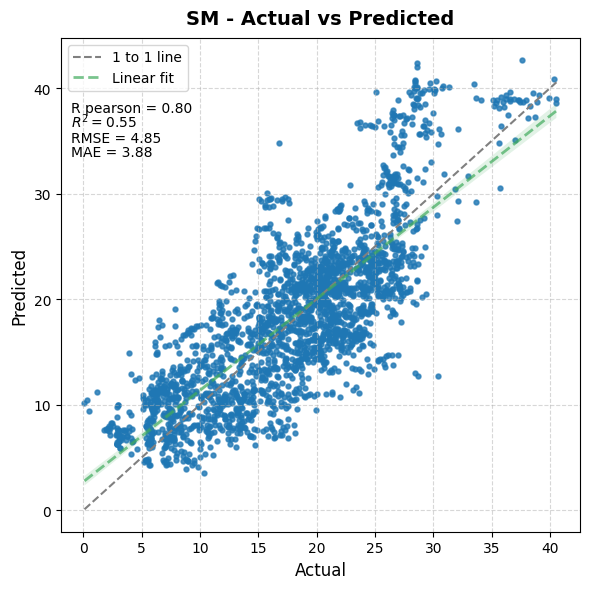

In [36]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6, s=14)
plt.plot(
    [min(y_test), max(y_test)], 
    [min(y_test), max(y_test)], 
    color='grey', linestyle='--',label='1 to 1 line'
)
sns.regplot(
    x=y_test, 
    y=y_pred_test, 
    line_kws={"color": "#41ab5d", "alpha": 0.7, "lw": 2, "linestyle": "dashed", "label": "Linear fit"},
    scatter_kws={'s': 7, 'alpha': 0.5}
)
base_y = 0.85  
step = 0.03   

plt.xlabel("Actual", fontsize=12)
plt.ylabel("Predicted", fontsize=12)
plt.title("SM - Actual vs Predicted", fontsize=14, weight='bold', pad=10)
plt.annotate(f'R pearson = {r:.2f}', xy=(0.02, base_y), xycoords='axes fraction', color='black')
plt.annotate(f'$R^2 = {r2:.2f}$', xy=(0.02, base_y - step), xycoords='axes fraction', color='black')
plt.annotate(f'RMSE = {rmse:.2f}', xy=(0.02, base_y - 2 * step), xycoords='axes fraction', color='black')
plt.annotate(f'MAE = {mae:.2f}', xy=(0.02, base_y - 3 * step), xycoords='axes fraction', color='black')
plt.legend(loc="upper left")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Spatial Reliability  of the model

In [37]:
df_x_train["Station"] = df_valid_train_clean["Station"]
df_x_train["Date"] = df_valid_train["Date"]

df_x_test["Station"] = df_valid_test_clean.reset_index(drop=True)["Station"]
df_x_test["Date"] = df_valid_test.reset_index(drop=True)["Date"]

In [38]:
feats = [*df_x_train.iloc[:, :11].columns]
feats

['16',
 '52',
 '108',
 '120',
 'ELEV',
 'ETref',
 'weighted_sm',
 '20_RZSM_band1',
 '20_RZSM_band2',
 'Month',
 'DOY_UTC']

In [39]:
results_df, avg_metrics = loso_cv_ml(
    df_x_train,
    features=feats,
    target="INSITU_SM",
    group_col="Station",
    model=HistGradientBoostingRegressor(random_state=42, max_iter=300)
)

print(results_df)
print("\nAverage metrics across stations:")
print(avg_metrics)

   Station  Pearson_r         R2       RMSE        MAE
0     1.01   0.871116   0.270919   8.186263   7.119833
1     1.03   0.878849  -1.377018  18.516923  16.857079
2     1.06   0.827171 -23.348768  28.600116  24.134627
3     1.07   0.879038   0.749006   5.240597   3.489231
4     1.08   0.946990  -0.324023   4.063338   2.736699
5     1.09   0.718213  -4.183400  11.383633   9.512648
6      1.1   0.790684  -1.649325   7.788115   6.904444
7     2.03   0.597466   0.053554   3.633898   2.914653
8     2.04   0.795990  -0.157145   4.499825   3.511384
9     2.05   0.814672   0.616654   3.319921   2.448674
10    2.06   0.807734   0.034565   5.177615   4.354573
11    2.07   0.611373  -1.834756   9.724946   8.890536
12    2.08   0.616691  -0.579651  11.001998   9.611395
13    2.09   0.877141  -1.727127  25.021887  23.579489
14     2.1   0.859664   0.546246   5.674369   5.109367
15    2.11   0.754939  -2.372755  24.868235  22.706844
16    3.01   0.620979  -0.298485   9.358454   7.958552
17    3.02

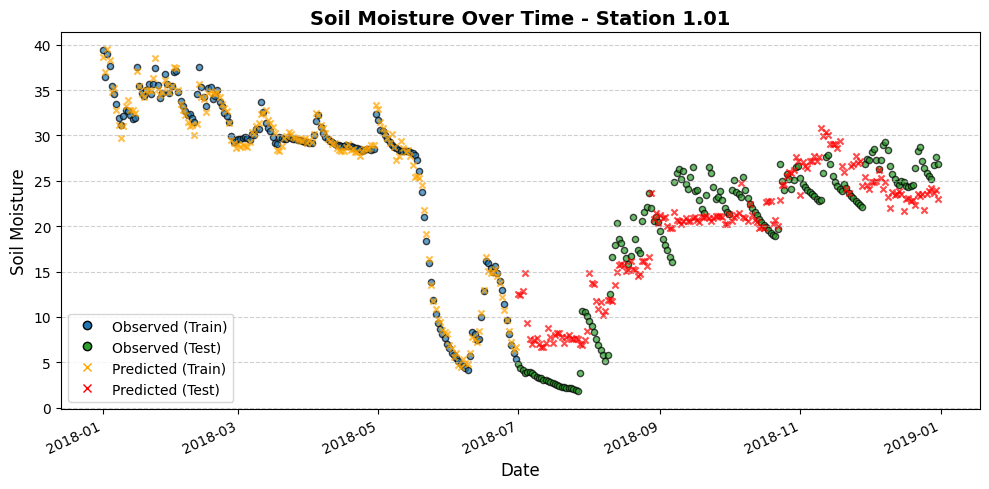

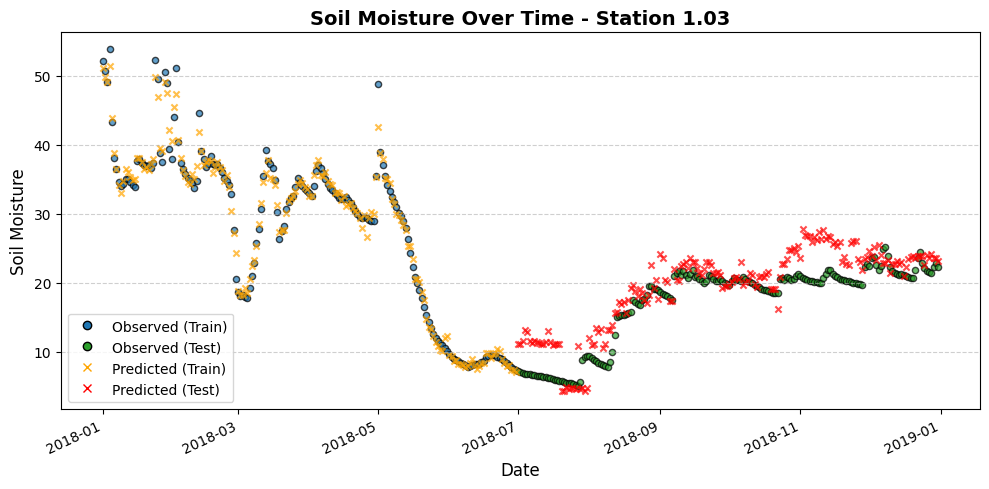

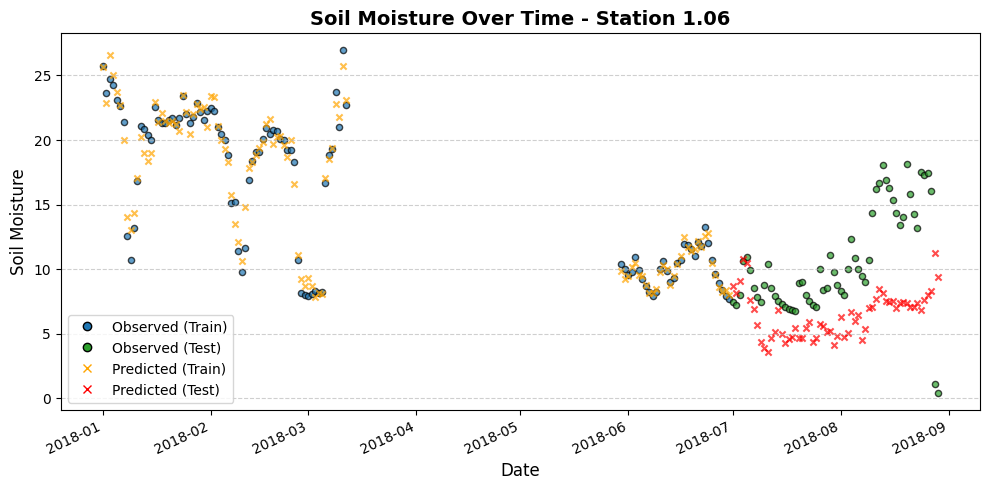

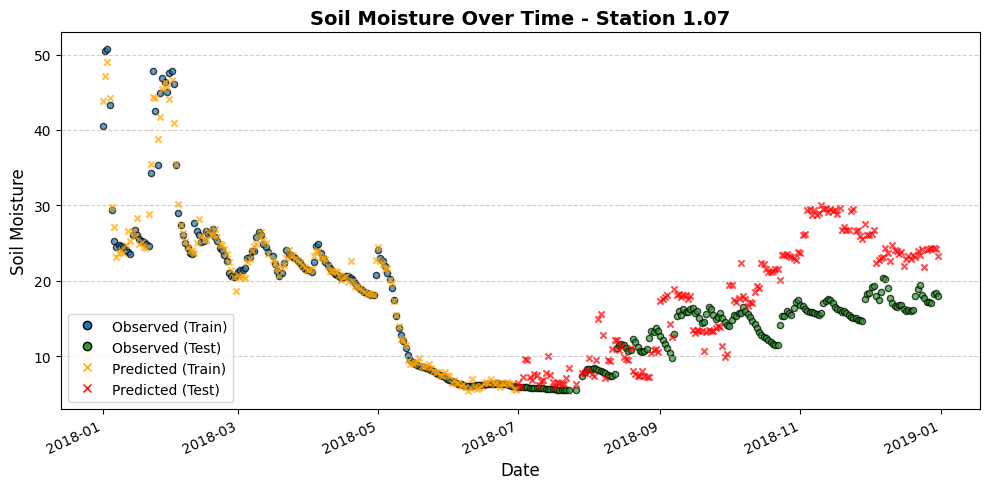

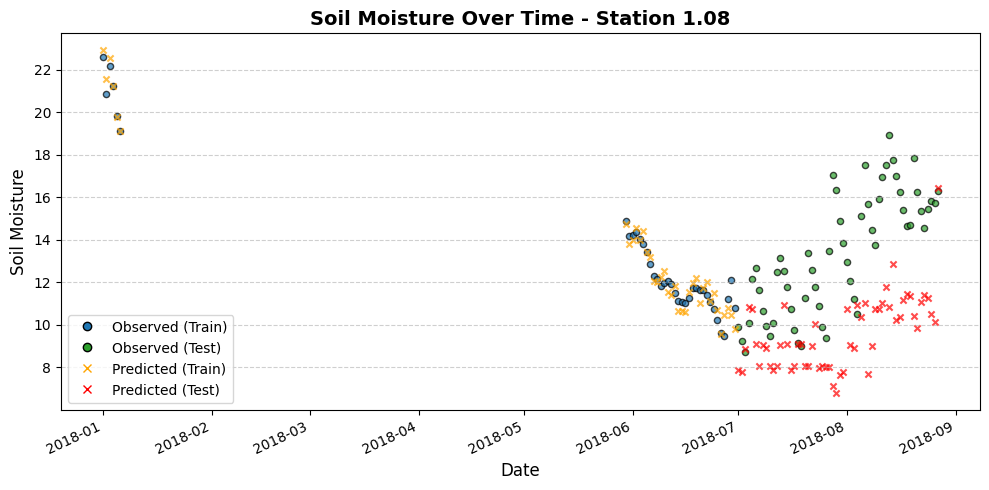

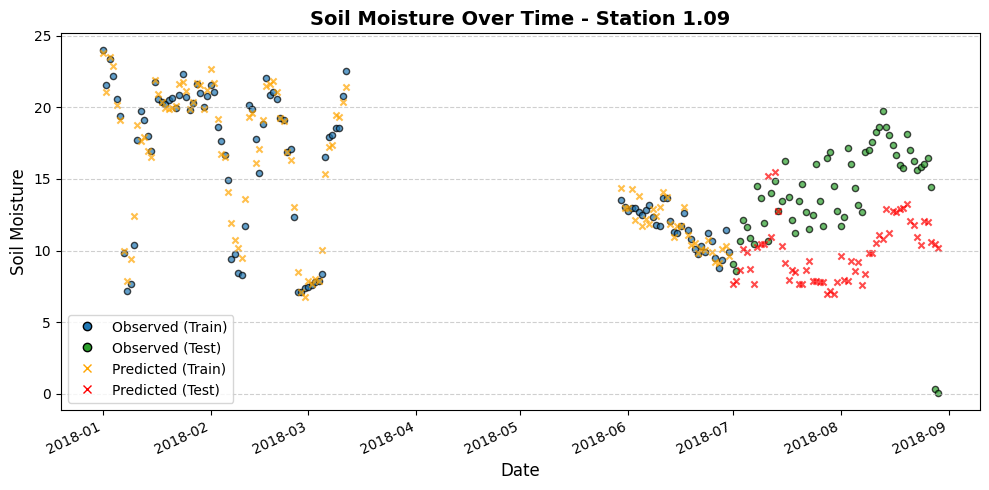

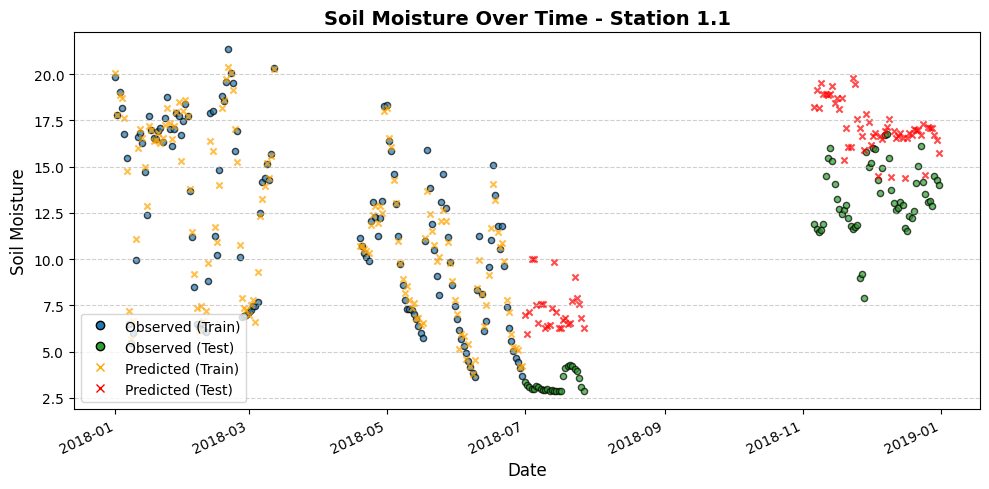

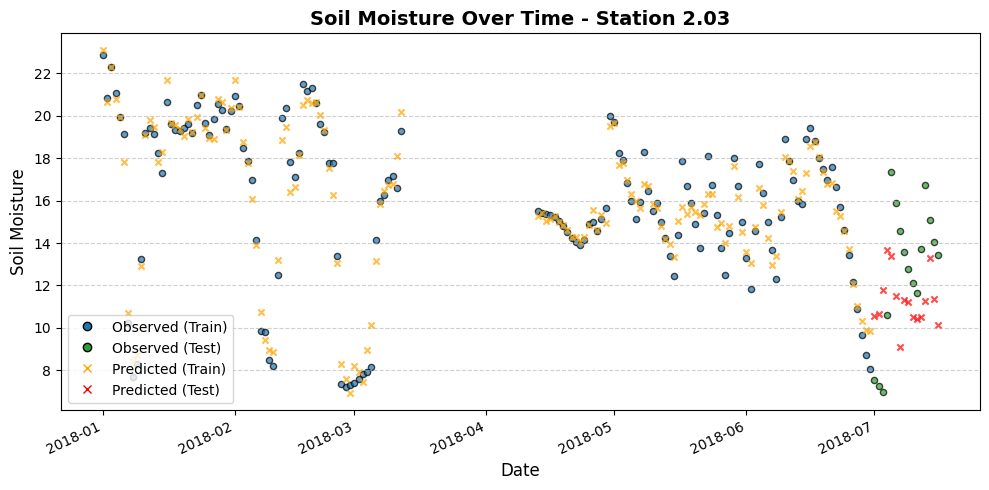

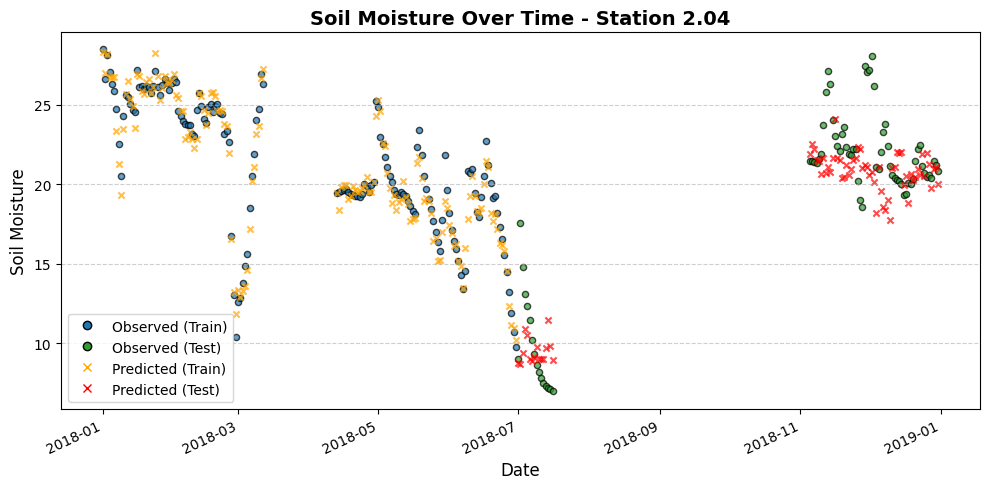

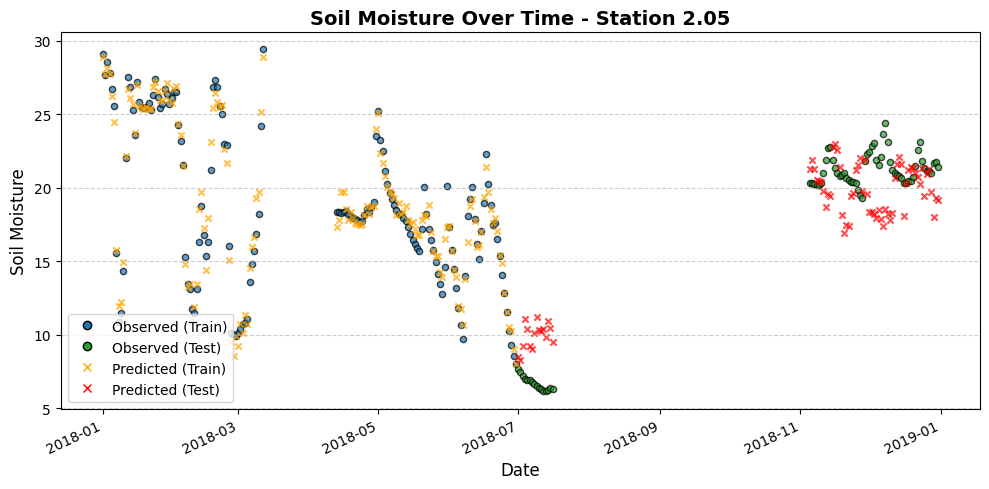

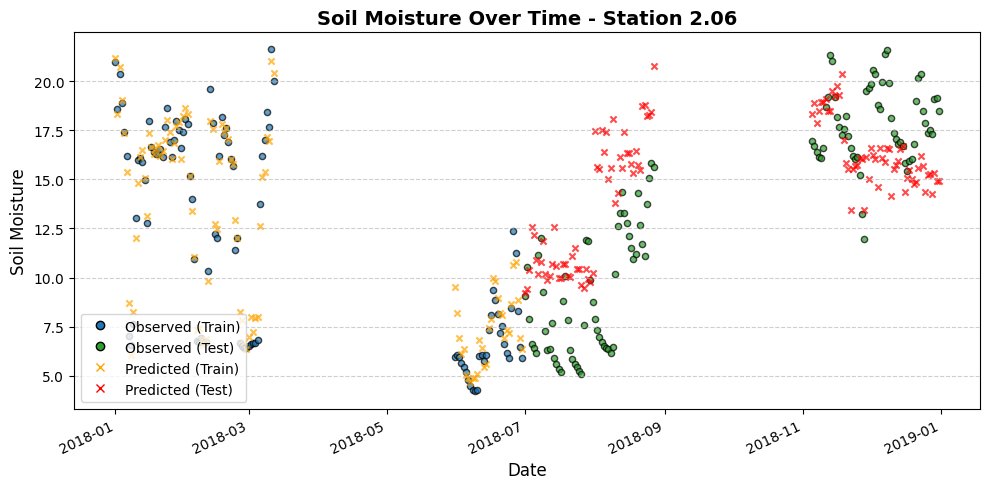

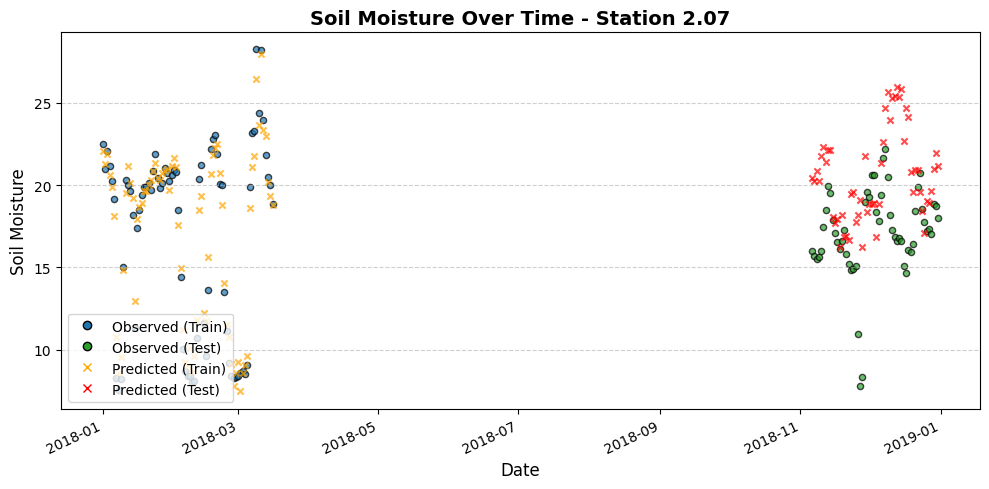

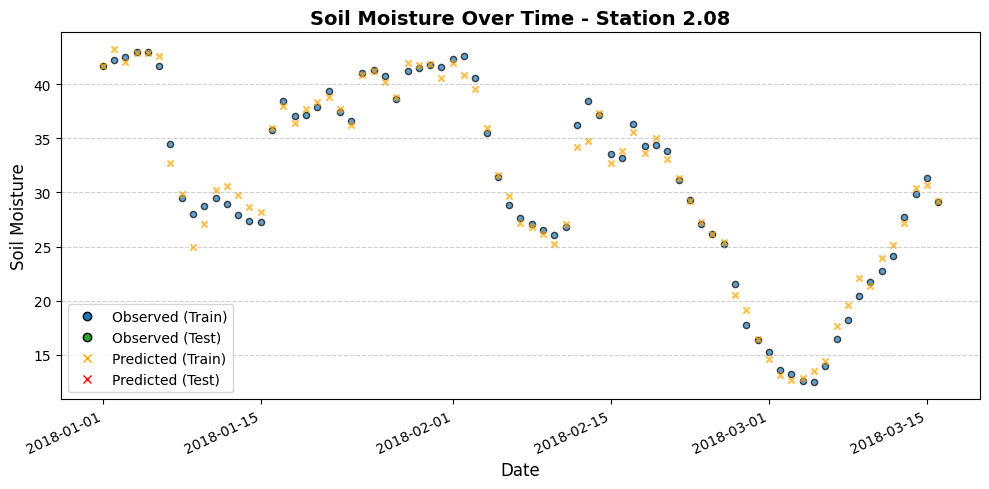

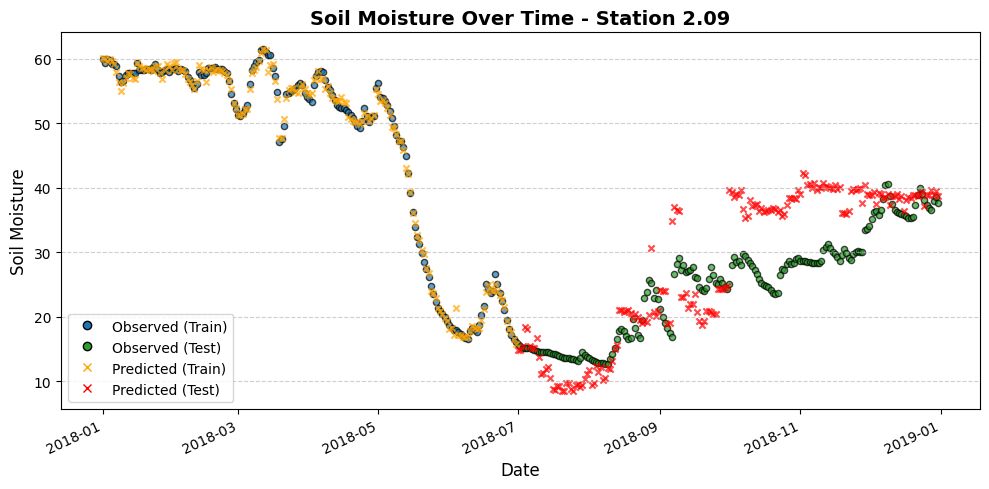

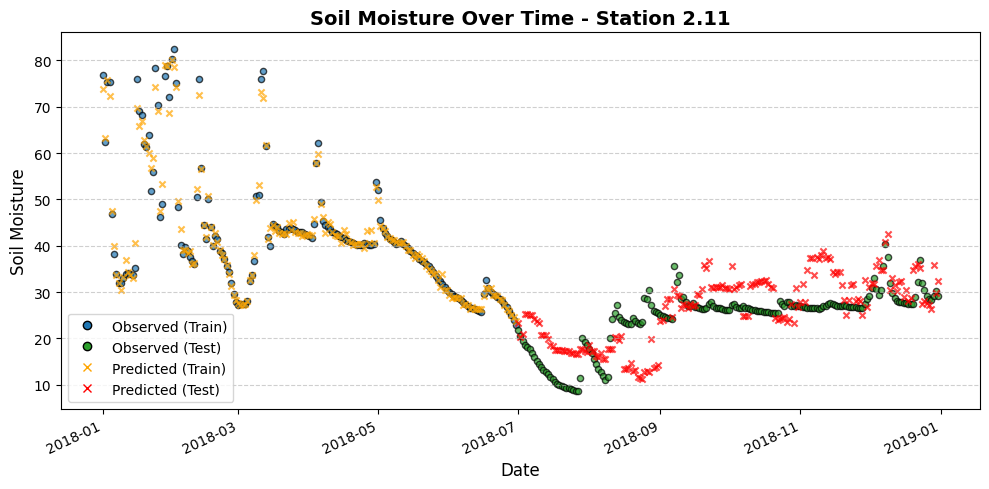

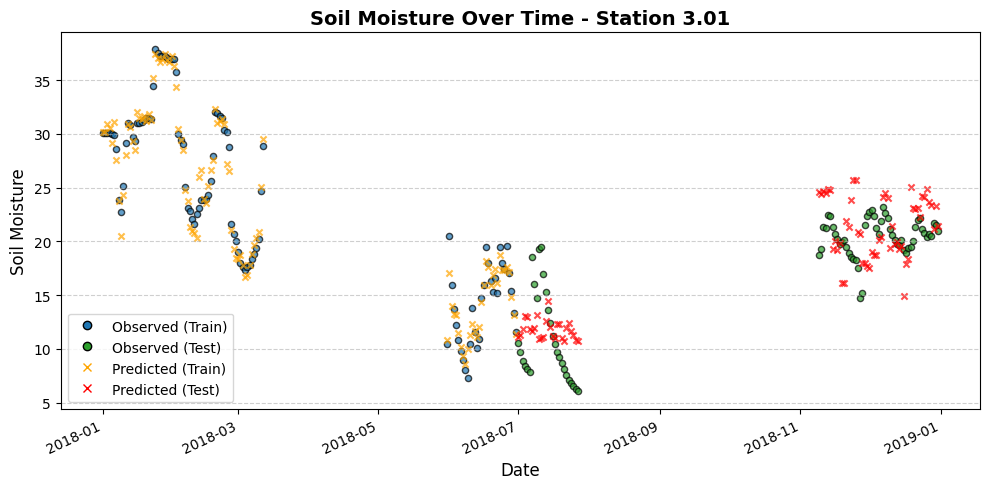

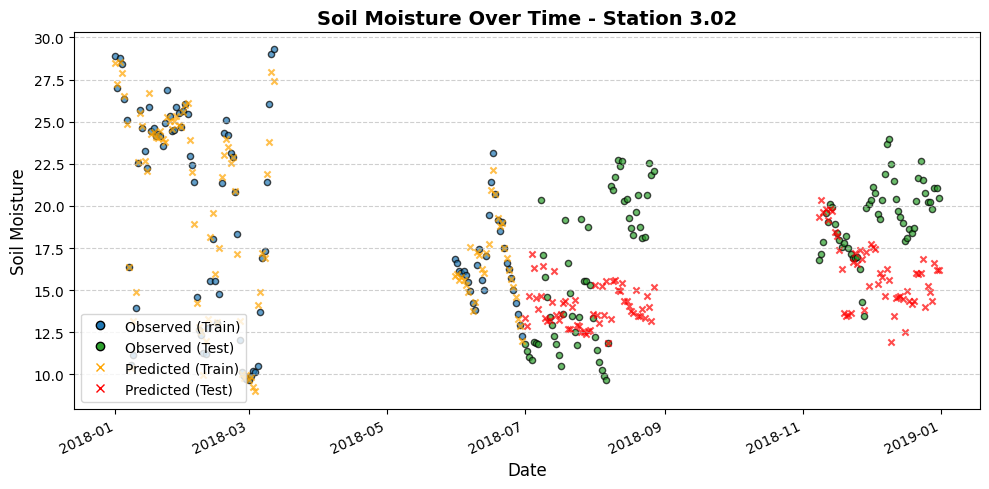

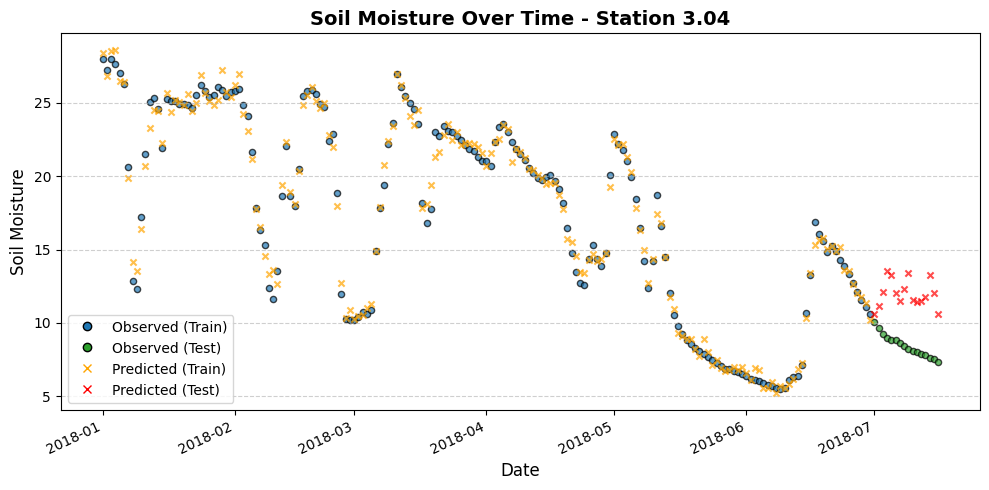

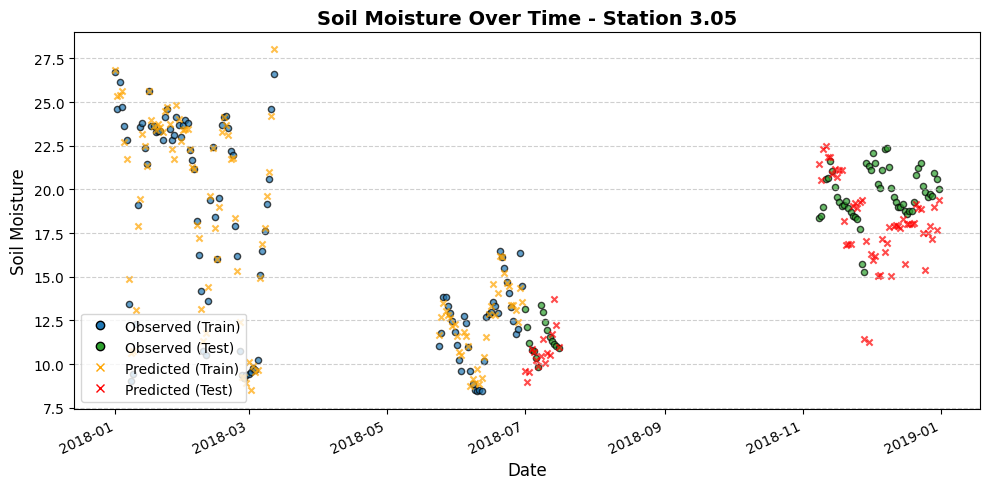

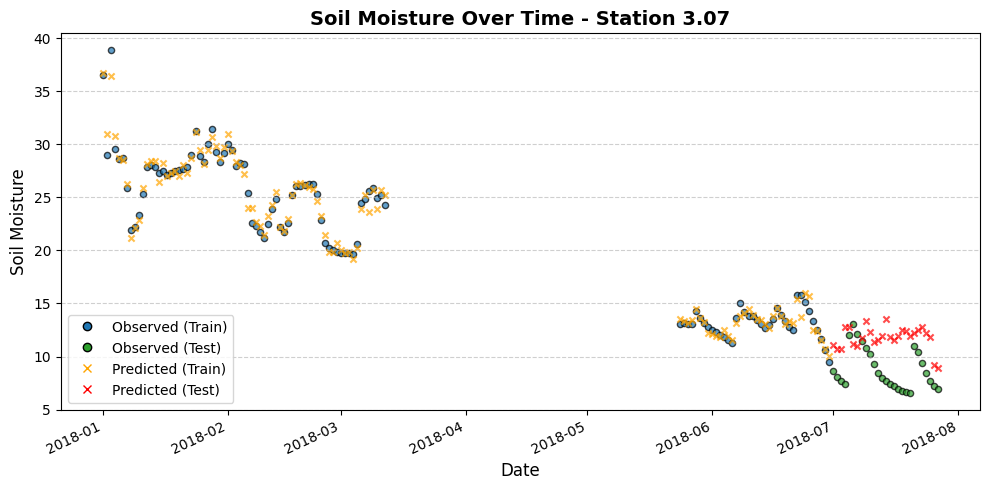

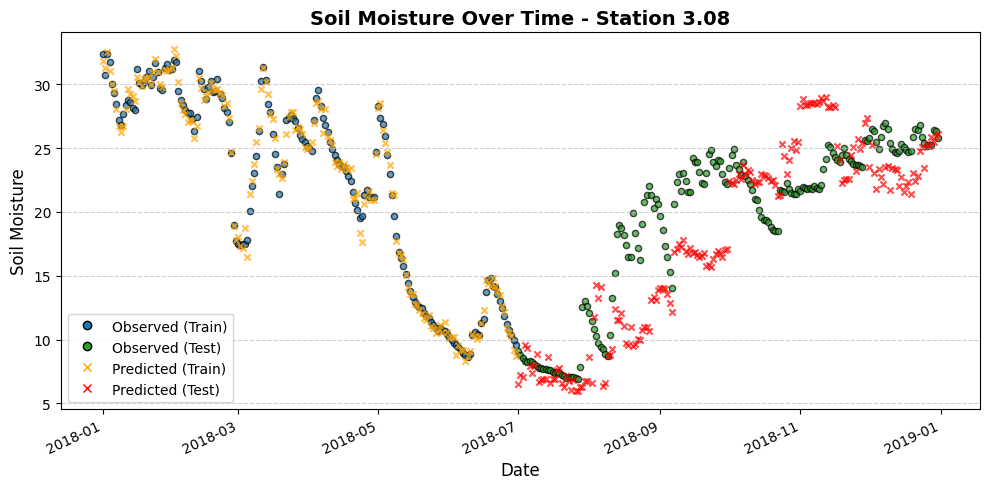

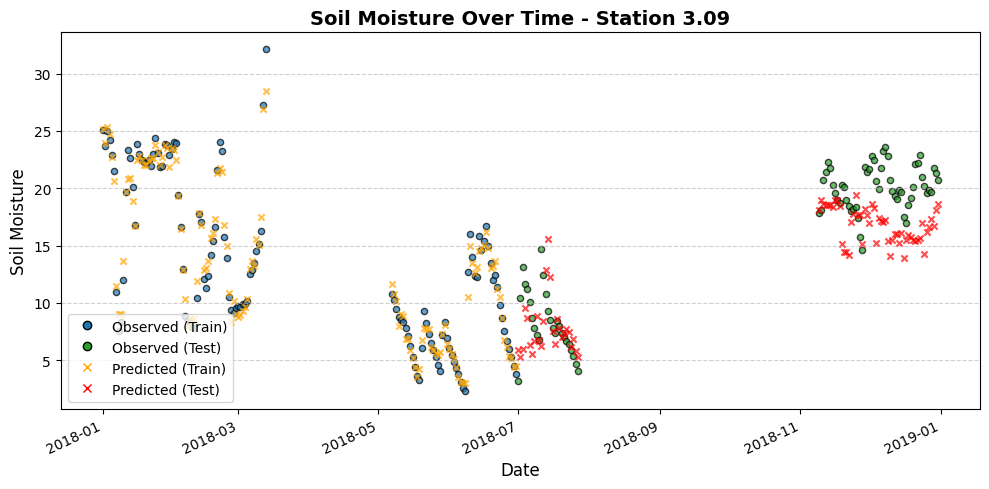

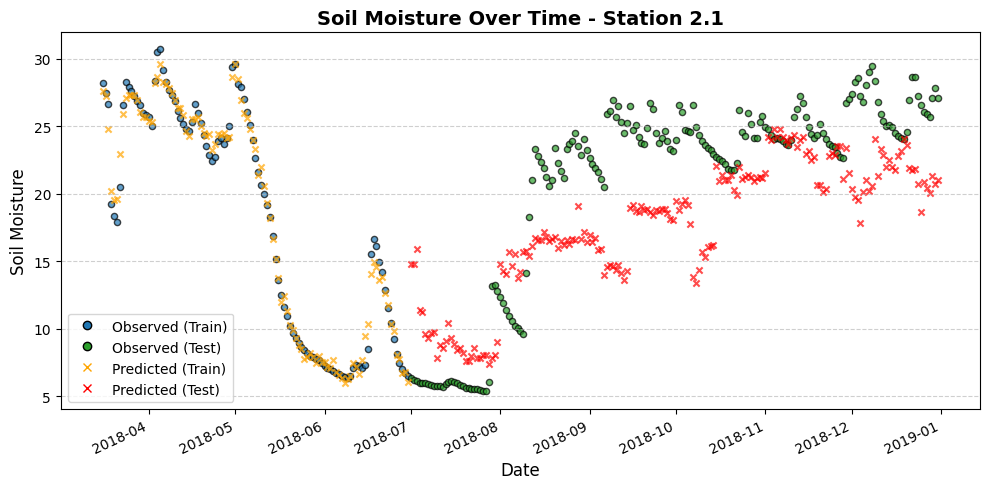

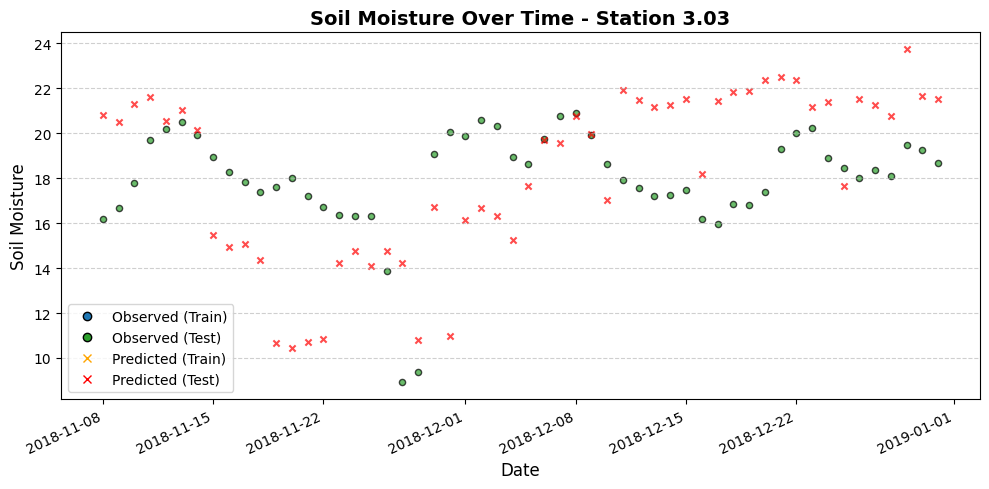

In [40]:
plot_predictions_by_station(
    df_train=df_x_train,
    df_test=df_x_test,
    model=hgb,
    features=feats,
    target_col="INSITU_SM",
    date_col="Date",
    station_col="Station"
)

# Features Importance

In [41]:
from sklearn.inspection import permutation_importance

In [42]:
importance_results = permutation_importance(
    hgb, X_train, y_train,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [43]:
importance_df = pd.DataFrame({
    'Feature': df_x_train.iloc[:, :11].columns,
    'Importance Mean': importance_results.importances_mean,
    'Importance Std': importance_results.importances_std
}).sort_values(by='Importance Mean', ascending=False)
importance_df

,Feature,Importance Mean,Importance Std
4,ELEV,0.538650,0.010830
8,20_RZSM_band2,0.513047,0.013799
10,DOY_UTC,0.268019,0.007651
0,16,0.107313,0.004428
2,108,0.052598,0.001060
1,52,0.028005,0.000368
7,20_RZSM_band1,0.025087,0.000221
3,120,0.024823,0.000912
5,ETref,0.020891,0.000449
6,weighted_sm,0.020194,0.000254


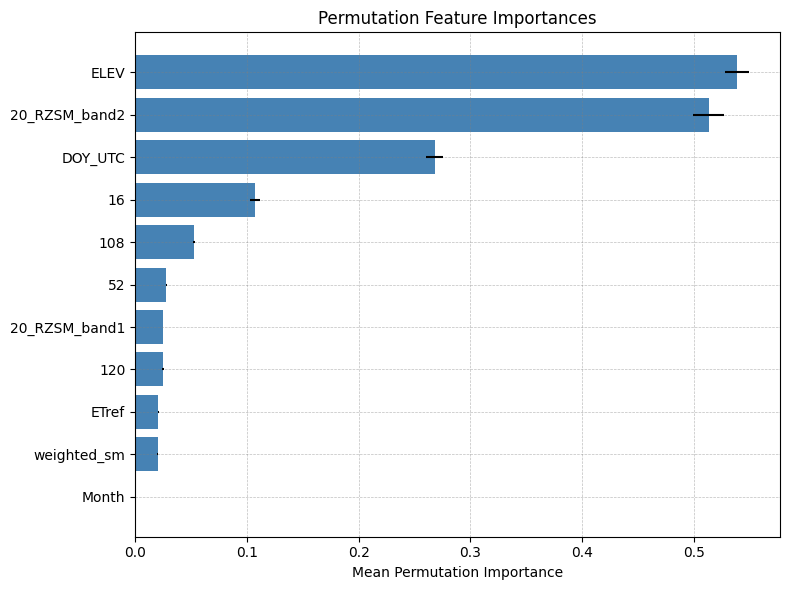

In [44]:
plt.figure(figsize=(8, 6))
plt.barh(
    importance_df['Feature'],
    importance_df['Importance Mean'],
    xerr=importance_df['Importance Std'],
    color=['steelblue'] * 20 + ['orange']  # highlight "Others"
)
plt.gca().invert_yaxis()

plt.xlabel('Mean Permutation Importance')
plt.title('Permutation Feature Importances')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

# Extra

Lets try to train the model without the elevation. 

In [45]:
extra_fatures_v2 = [
    "ETref", 
    "weighted_sm",
    "20_RZSM_band1", 
    "20_RZSM_band2",
    "Month", 
    "DOY_UTC"
]

In [46]:
df_valid_train[extra_fatures_v2]

,ETref,weighted_sm,20_RZSM_band1,20_RZSM_band2,Month,DOY_UTC
0,0.345211,30.385803,34.006161,26.765446,1,1.0
1,0.334450,30.350887,33.716316,26.985458,1,1.0
2,0.340658,45.481903,46.726318,44.237488,1,1.0
3,0.342896,32.120586,35.675045,28.566128,1,1.0
4,0.349677,29.649515,32.880177,26.418854,1,1.0
...,...,...,...,...,...,...
3007,5.935028,9.200000,5.000000,13.400001,6,181.0
3008,5.917080,18.651784,17.722881,19.580687,6,181.0
3009,5.934308,42.068348,39.668007,44.468689,6,181.0
3010,5.738082,13.180953,5.000000,21.361906,6,181.0


In [47]:
X_train_v2 = np.hstack([X_train_np[:, [16, 52, 108, 120]], df_valid_train[extra_fatures_v2].values])
X_test_v2 = np.hstack([X_val_np[:, [16, 52, 108, 120]], df_valid_test[extra_fatures_v2].values])

In [48]:
X_train_v2.shape, X_test_v2.shape

((3012, 10), (2317, 10))

In [49]:
hgbv2 = HistGradientBoostingRegressor(random_state=42, max_iter=300)
hgbv2.fit(X_train_v2, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",300
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide ` and:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_categorical.py`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 

In [50]:
y_pred_test_v2 = hgbv2.predict(X_test_v2)

In [51]:
test_stats_v2 = regression_metrics(y_test, y_pred_test_v2, label="Test", return_results=True)
test_stats_v2

Test Pearson r: 0.7416
Test R²: 0.5102
Test RMSE: 5.0377
Test MAE: 4.1176



{'Pearson_r': np.float64(0.7415855315003397),
 'R2': 0.5102188834121539,
 'RMSE': np.float64(5.037730218904404),
 'MAE': 4.117576162152876}

In [52]:
importance_results_v2 = permutation_importance(
    hgbv2, X_train_v2, y_train,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [53]:
importance_dfv2 = pd.DataFrame({
    'Feature':selected_embeddings + extra_fatures_v2,
    'Importance Mean': importance_results_v2.importances_mean,
    'Importance Std': importance_results_v2.importances_std
}).sort_values(by='Importance Mean', ascending=False)
importance_dfv2

,Feature,Importance Mean,Importance Std
7,20_RZSM_band2,0.715400,0.018630
9,DOY_UTC,0.269842,0.006062
0,16,0.150181,0.004816
2,108,0.138033,0.002468
3,120,0.065938,0.001735
1,52,0.061843,0.001526
4,ETref,0.029983,0.001242
5,weighted_sm,0.027307,0.000332
6,20_RZSM_band1,0.018617,0.000521
8,Month,0.001735,0.000056


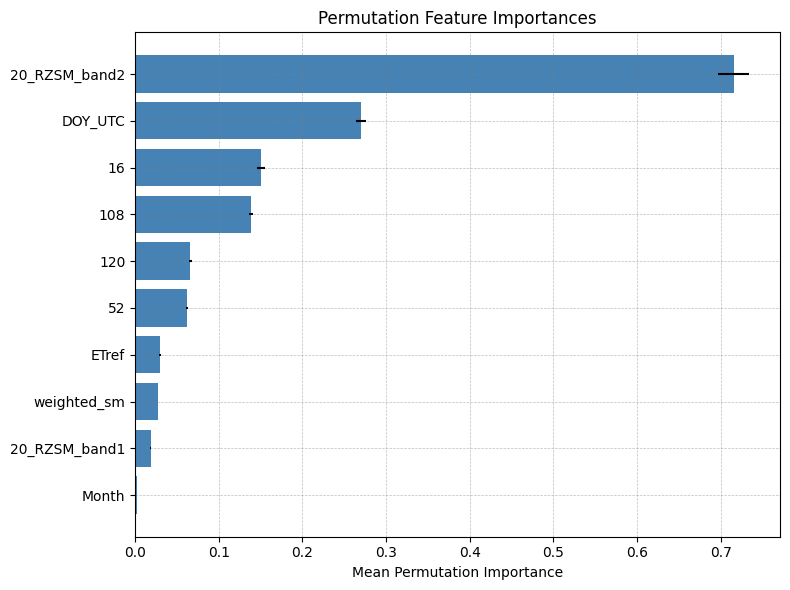

In [54]:
plt.figure(figsize=(8, 6))
plt.barh(
    importance_dfv2['Feature'],
    importance_dfv2['Importance Mean'],
    xerr=importance_dfv2['Importance Std'],
    color=['steelblue'] * 20 + ['orange']  # highlight "Others"
)
plt.gca().invert_yaxis()

plt.xlabel('Mean Permutation Importance')
plt.title('Permutation Feature Importances')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()